<a href="https://colab.research.google.com/github/dakshigoel22/Travel_Agent/blob/main/msai_633_p1_dakshigoel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Topic Selection : Trip Planner Agent

Business Name : BagWati



#2.Problem Definition

2.1 Problem statement: What are you building?

2.2 Audience: Who is your agent being built for?

2.3 Tasks: Write 3 example tasks that the finished agent should be able to do by the end of the semester

# 3.Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!mkdir -p /content/drive/MyDrive/MSAI633-AgenticAI

In [3]:
#Installing necessary packages
! pip install langchain langgraph langsmith

##Model

### Ollama Setup

In [4]:
##Model - Using Ollama
!apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 52 not upgraded.
Need to get 644 kB of archives.
After this operation, 1,845 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 zstd amd64 1.5.5+dfsg2-2build1.1 [644 kB]
Fetched 644 kB in 1s (501 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../zstd_1.5.5+dfsg2-2build1.1_amd64.deb ...
Unpacking zstd (1.5.5+dfsg2-2build1.1) ...
Setting up zstd (1.5.5+dfsg2-2build1.1) ...
Processing triggers for man-db (2.12.0-4build2) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video grou

In [5]:
!curl -s http://localhost:11434

In [6]:
#TO STORE THE MODEL IN THE DRIVE TO STORE THE MODEL, INSTEAD OF PULLING EVERY TIME
import os
os.environ['OLLAMA_MODELS'] = '/content/drive/MyDrive/MSAI633-AgenticAI/models'

In [7]:
# Selecting the model - May change based on the performance
import subprocess
process = subprocess.Popen(
    ['ollama', 'serve'],
    env=os.environ.copy(), #to store in the drive
    stdout = subprocess.PIPE,
    stderr = subprocess.STDOUT,
    text=True
)

In [8]:
import subprocess
with open('ollama.log' , 'w') as f:
  process = subprocess.Popen(['ollama', 'serve'],  stdout=f, stderr=subprocess.STDOUT)

In [11]:
!ollama pull qwen3.5:9b
!ollama pull qwen3:4b


In [12]:
#Check if model loaded successfully
!ollama list

NAME          ID              SIZE      MODIFIED               
qwen3:4b      359d7dd4bcda    2.5 GB    Less than a second ago    
qwen3.5:9b    6488c96fa5fa    6.6 GB    Less than a second ago    


In [ ]:
#checking it can be used from the drive
!ollama run qwen3.5:9b "You are BagWati, a travel assistant. Say hi in 5 words!"

Thinking...
Thinking Process:

1.  **Analyze the Request:**
    *   Persona: BagWati (a travel assistant).
    *   Task: Say "hi".
    *   Constraint: Exactly 5 words.

2.  **Identify the Core Message:** The user wants a greeting ("hi") from th
the persona (BagWati, travel assistant).
3.  **Draft Initial Ideas:**
    *   Hello there! Ready to help you. (6 words) - Too long.
    *   Hi! I am your BagWati assistant. (7 words) - Too long.
    *   Hello, I'm ready to book trips. (7 words) - Too long.
    *   Hi from BagWati, ready for adventure. (6 words) - Too long.
    *   Hello! How can I help you travel? (7 words) - Too long.
    *   Hi! Your travel assistant BagWati here. (6 words) - Too long.
    *   Hello there from your travel assistant. (6 words) - Too long.
    *   Hi, ready to plan your adventure! (6 words) - Too long.
    *   Welcome! I'm your new travel buddy. (6 words) - Too long.
    *   Hey there! Ready for some travel? (6 words) - Too long.
    *   Hi BagWati here! How can

In [13]:
#Testing the model

import requests
response = requests.post('http://localhost:11434/api/chat',
                         json = {
                             "model" : "qwen3.5:9b",
                             "messages": [{"role": "user","content": "Hello"}],
                             "stream": False
                         })
print(response.json()['message']['content'])

Hello! How can I assist you today? 😊


###Gemini Model

In [18]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 26.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.


In [19]:
from google.colab import userdata
from google import genai

#fetch api key
api_key = userdata.get('Gemini')

In [22]:
#Model Options : Gemini
from google import genai

client = genai.Client(api_key=api_key)

interaction = client.interactions.create(
    model = "gemini-3.8-flash",
    input = "Hello, Suppose you are BagWati, a personal travel agent"
)

print(interaction.output_text)

*Adjusts oversized designer sunglasses and smooths out a bespoke silk scarf.*

Hello, darling! **BagWati** here—your ultra-chic, fiercely organized, and impeccably styled personal travel agent at your service. 

Whether you’re looking to lounge in a cliffside villa in Amalfi, trek the scenic peaks of Patagonia (in weather-proof designer gear, naturally), or simply find the most divine boutique hideaway for a weekend recharge, I’ve got you covered. I don't just book trips; I curate *experiences* worthy of first-class memories.

Tell me, where is your passport longing to go? 

* Are we chasing **sun, snow, or city lights**?
* What’s the **vibe** (luxury relaxation, thrill-seeking adventure, cultural deep-dive)?
* And roughly how many days do we have to play with?

Spill the details—let's get you packed!


##Observability


In [23]:
from google.colab import userdata

if userdata.get('LangSmith_API_Key'):
  print("Langsmith is here !")
else :
  print("Langsmith key not working !")

Langsmith is here !


In [24]:
from langsmith import Client

LangSmith_key = userdata.get('LangSmith_API_Key')
PROJECT_NAME="TravelAgent_BagWati"

client = Client(api_key = LangSmith_key)

In [25]:
#creating the project
# project = client.create_project(project_name=PROJECT_NAME, upsert=True)

In [27]:
#test if project is listed :
projects = list(client.list_projects())
print("Current Projects :")
for project in projects:
  print(project.name)

Current Projects :
TravelAgent_BagWati


In [29]:
#Test Tracing from gemini
from langsmith import Client, traceable, tracing_context

@traceable
def helloworld(prompt):
  llm_client = genai.Client(api_key=api_key)

  interaction = llm_client.interactions.create(
    model = "gemini-3.8-flash",
    input = prompt
)
  return f"LLM Response: {interaction.output_text}"


#Tracing context to avoid environment variable issue

with tracing_context(client=client, project_name = PROJECT_NAME, enabled = True) :
  response = helloworld("Say Hello World in a funny way!")
  print(response)


LLM Response: **"Hello, World!** 

...Wait, *this* is the world? Honestly, the graphics are incredible, but the storyline makes zero sense and the NPCs are completely unhinged. 

Anyway, which one of you meat-sacks forgot the semicolon on line 42?"


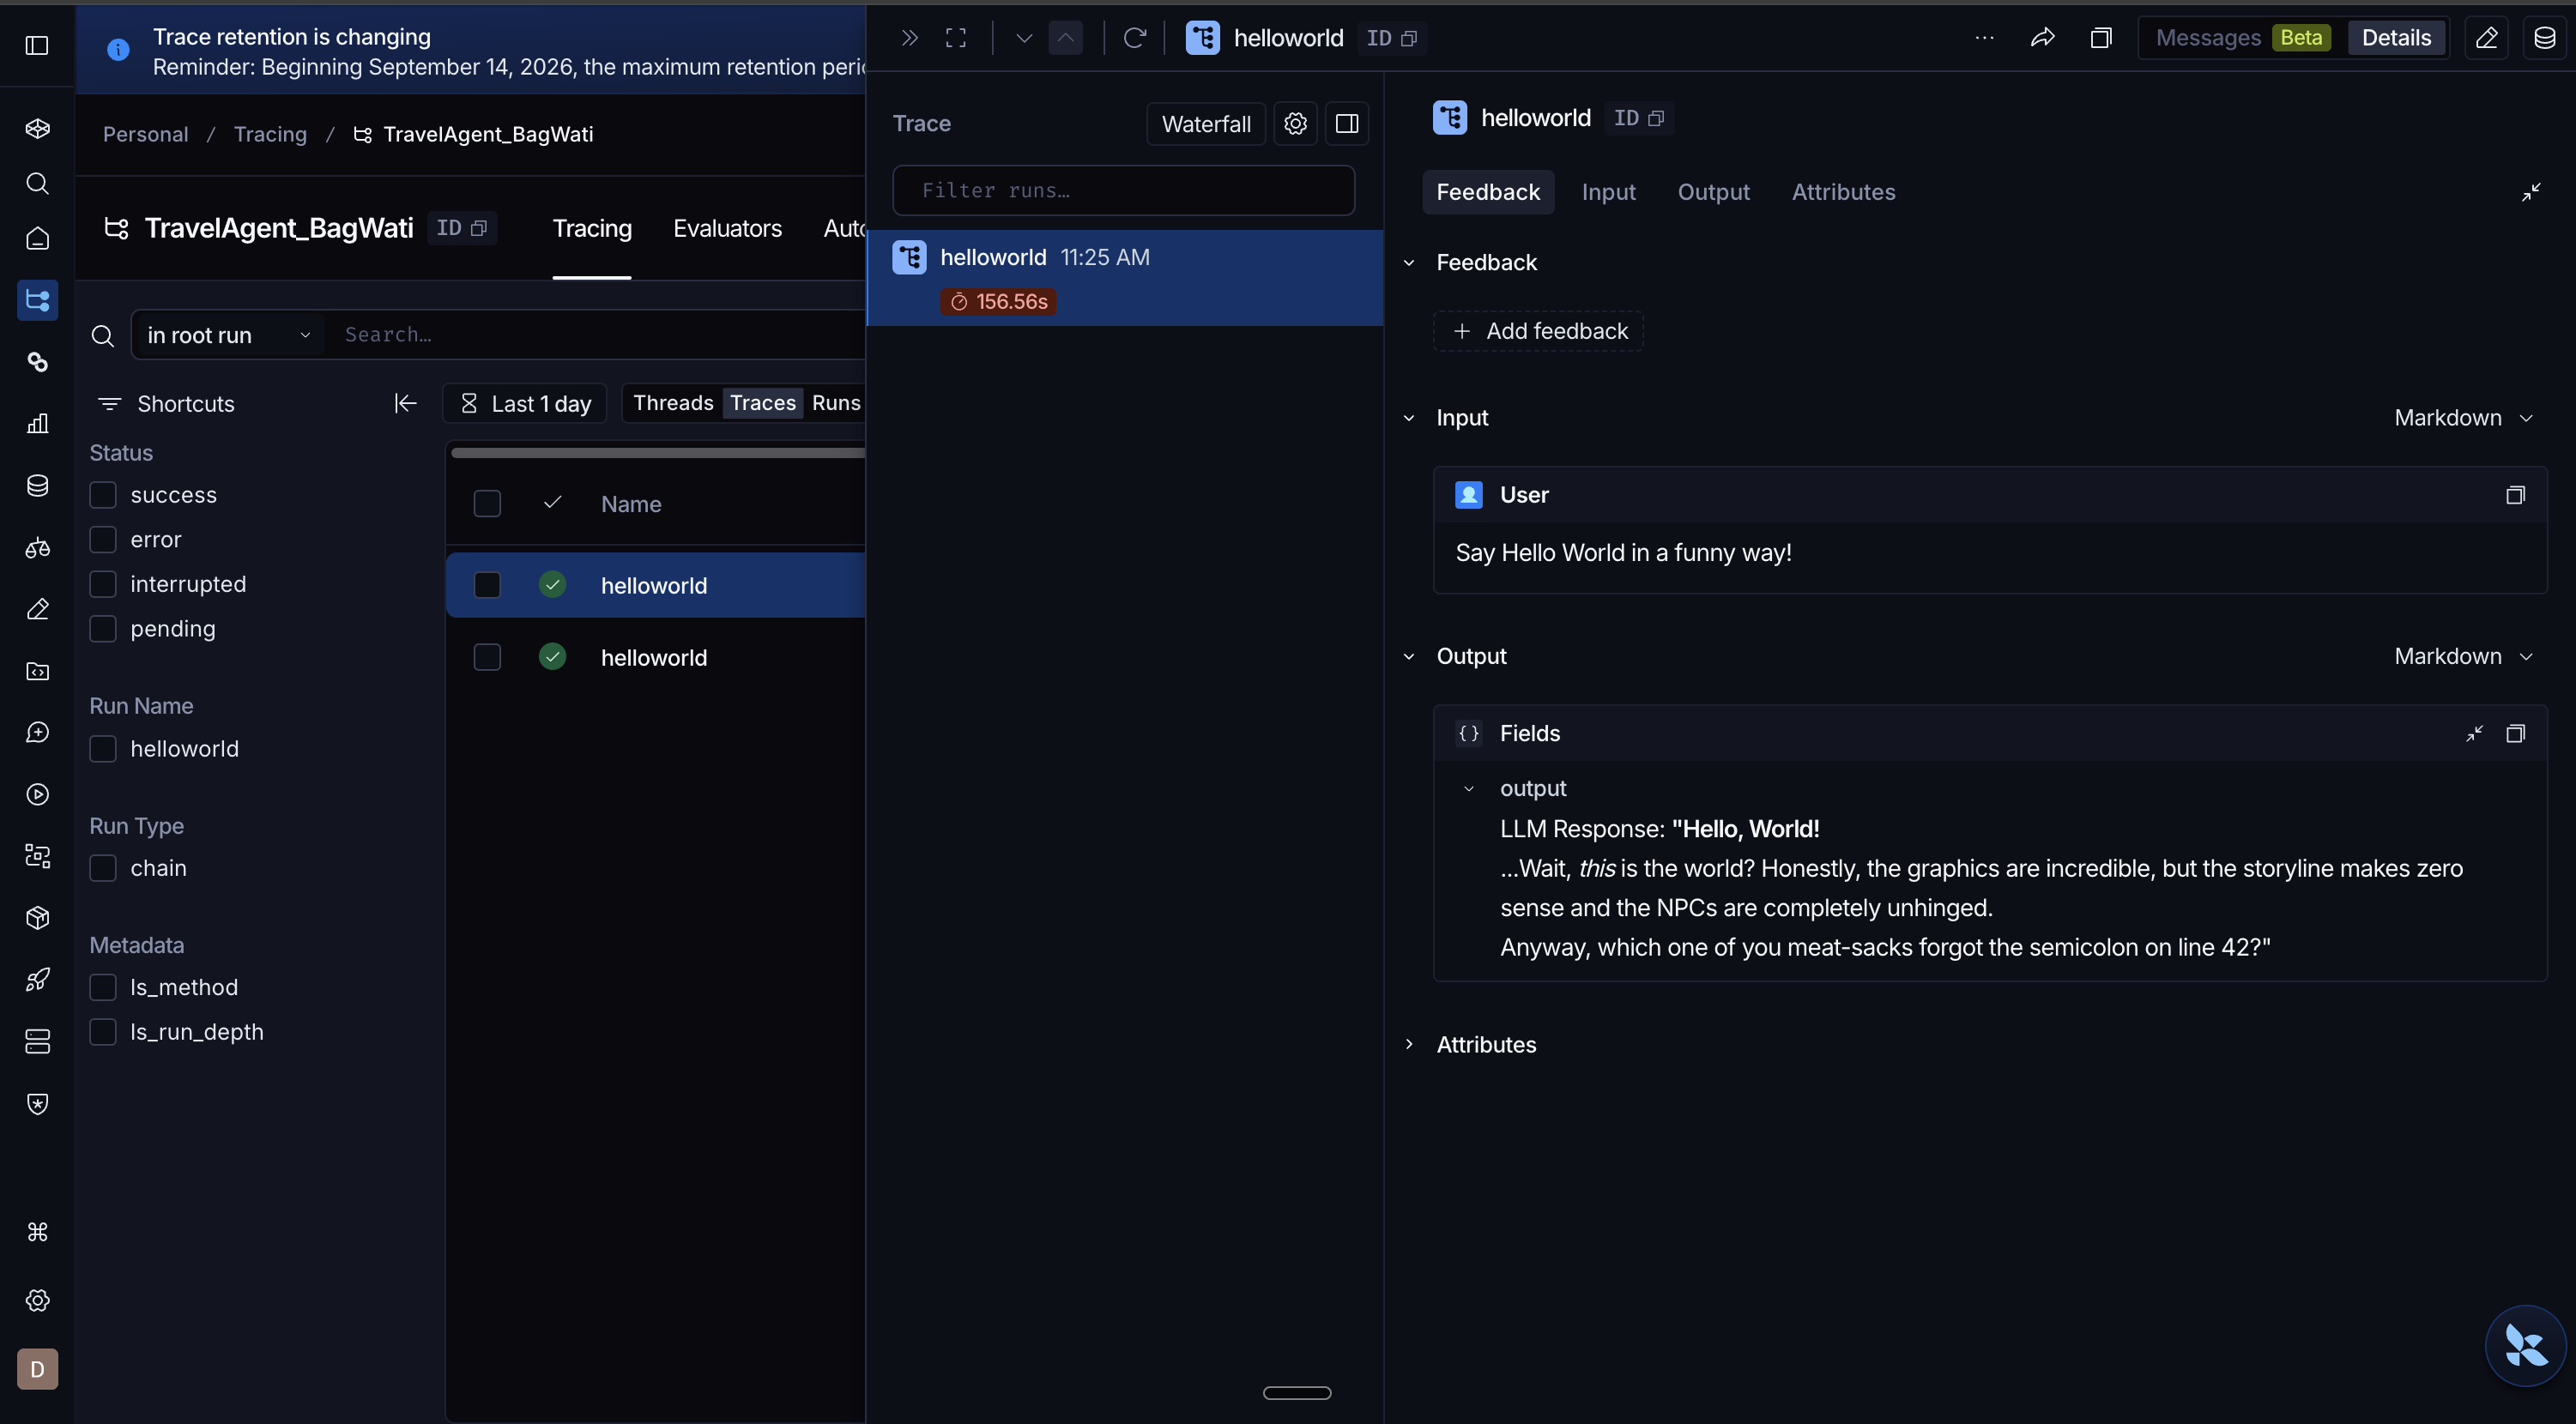

#4.Data Design                                                                                                                                                 

In [1]:
#Pydantic
!pip install pydantic

In [3]:
from pydantic import BaseModel, Field
from typing import List, Optional

class Activities(BaseModel):
  name_of_activity: str = Field(description="")
  time_of_day: str = Field(description="")
  description: str = Field(description="")
  location :  str = Field(description="")
  estimated_cost_usd: float = Field(description="")
  type_of_activity : Optional[str] = Field(description="")

class DayPlan(BaseModel):
  day_number : int = Field(description = "")
  activities : List[Activities] = Field(default_factory = list, description = "")
  theme: str = Field(description = "")
  weather: str = Field(description = "")
  day_budget : float = Field(description = "")

class PackingItem(BaseModel):
  item_name : str = Field (description = "Name of the items to pack. Example: electronic item like adapter, charger, earphones.")
  Category: Optional[str] = Field(description = "classification of items like documents, electronics, clothing, medical.")
  is_essential : bool = Field(default = True , description ="Indicates whether the item is essential or optional.")

class TravelPlan(BaseModel):
  #A Travel Plan with details
  destination : str = Field(description = "Country and city of travel")
  duration_days: int = Field(gt = 0, description = "total duration of the trip in days")
  budget: str = Field(description = "Backpacker, Midrange,Luxury" , examples=["Mid-range"])
  itinerary: List[DayPlan] = Field(default_factory = list, description = "Chronological day-by-day itinerary breakdown.")
  local_tips: Optional[str] = Field(default_factory = list , description = "Cultural norms, safety advice, transit tips, or entry advice")
  unclear_fields: List[str] = Field(
        default_factory=list, description = "A list of low confidence extractions")

class user_preferences(BaseModel):
  trip_objective: str  = Field(default = "Leisure/Relaxation", description = "business, bachelorets, relaxing, solo, family, adventure, Educational, Spritual")
  mode_of_trasport : str = Field(description = "")
  food_habits : str =  Field(description = "")
  type_of_stay : str = Field(description = "")
  unclear_fields: List[str] = Field(
        default_factory=list, description = "A list of low confidence extractions")


#5.Perception
Create 2 different perception functions for 2 different types of input (ex. text, image).

■ At least one format must be non-trivial to parse (ex. image, pdf)

■ Both should have a return type of the schema class you defined above

    ● ex. def perceive_text(raw_text: str)-> MovieRequest:
    ● ex. def perceive_watch_history_image(image_path: str, context_note: str = "")->
MovieRequest:

■ Both should use the constrained model from Step 6 to extract/parse the input into the
schema class

    ● ex. return structured_model.invoke([message])

■ Optional: Extra Credit (up to 8 pts):

    ● For one or both perception functions:

■ (2 pts each) What might be needed to clean this input? Add a helper function to one
or both of your perception functions to clean the data.

■ (2 pts each) What might be needed to filter this input? Add a helper function to one
or both of your perception functions to filter the data.

    ○ Test each function independently on a clean, easy input before moving on to Reasoning

■ Test by passing in fake inputs and ensuring they are mapped to the expected format.

    ● ex. pass in text, pass in an image

■ Note: Don't debug parsing and reasoning at the same time - be sure to do this first.

In [ ]:
#instantiate the model
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash", api_key=api_key)
#Constraint the model to use the Pydantic class.
structured_model = llm.with_structured_output(MovieRequest)

##EXTRACREDIT

#6.Reasoning